###Kết nối Drive & cài đặt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn pandas numpy torch matplotlib seaborn

Mounted at /content/drive


In [ ]:
import os

KAGGLE_TOKEN = "your_kaggle_token_here"  

os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

print("✅ Đã set KAGGLE_API_TOKEN")

✅ Đã set KAGGLE_API_TOKEN


In [ ]:
!pip install kaggle -q

# Kiểm tra xem đã kết nối
!kaggle --version

Kaggle CLI 2.0.1


In [ ]:
# Tải dataset (dataset "5percent-cicddos2019-merged-and-processed-files")
!kaggle datasets download rodrigorosasilva/5percent-cicddos2019-merged-and-processed-files

Dataset URL: https://www.kaggle.com/datasets/rodrigorosasilva/5percent-cicddos2019-merged-and-processed-files
License(s): unknown
100% 103M/103M [00:00<00:00, 155MB/s] 



###🗂️  Tạo cấu trúc thư mục chuyên nghiệp

In [ ]:
from google.colab import drive
import os

#Mount Google Drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Internbase-security/transformer-32-feature'

folders = {
    'datasets/raw': 'Dữ liệu gốc tải từ Kaggle',
    'datasets/processed': 'Dữ liệu đã làm sạch, chuẩn hóa, chọn top 32 features',
    'models/checkpoints': 'Checkpoint trong quá trình huấn luyện',
    'models/final': 'Mô hình cuối cùng (pth, scripted.pt)',
    'notebooks/exploration': 'Notebook EDA và phân tích dữ liệu',
    'notebooks/training': 'Notebook huấn luyện chính',
    'results/metrics': 'File CSV/JSON kết quả đánh giá',
    'results/logs': 'Log huấn luyện (có thể dùng TensorBoard)',
    'utils': 'Các script hỗ trợ (ví dụ: data_loader.py, model.py)'
}

for folder, desc in folders.items():
    full_path = os.path.join(base_path, folder)
    os.makedirs(full_path, exist_ok=True)
    print(f"✅ Đã tạo: {full_path}  # {desc}")

print("\n🎉 Cấu trúc thư mục dự án đã sẵn sàng!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/datasets/raw  # Dữ liệu gốc tải từ Kaggle
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/datasets/processed  # Dữ liệu đã làm sạch, chuẩn hóa, chọn top 32 features
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/models/checkpoints  # Checkpoint trong quá trình huấn luyện
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/models/final  # Mô hình cuối cùng (pth, scripted.pt)
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/notebooks/exploration  # Notebook EDA và phân tích dữ liệu
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/notebooks/training  # Notebook huấn luyện chính
✅ Đã tạo: /content/drive/MyDrive/Internbase-security/transformer-32-feature/re

###🔑  Thiết lập Kaggle API Token (dạng chuỗi mới)

In [ ]:
import os

KAGGLE_TOKEN = "your_kaggle_token_here"  

os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN
!pip install kaggle -q
print("✅ Đã set KAGGLE_API_TOKEN")

✅ Đã set KAGGLE_API_TOKEN


###📥  Tải dữ liệu từ Kaggle vào thư mục datasets/raw

In [ ]:
# Tải dataset (nếu chưa có)
!kaggle datasets download rodrigorosasilva/5percent-cicddos2019-merged-and-processed-files

import shutil
zip_file = '/content/5percent-cicddos2019-merged-and-processed-files.zip'
dest_zip = os.path.join(base_path, 'datasets/raw', 'cicddos2019_5percent.zip')
shutil.move(zip_file, dest_zip)
print(f"✅ Đã lưu file zip vào: {dest_zip}")

Dataset URL: https://www.kaggle.com/datasets/rodrigorosasilva/5percent-cicddos2019-merged-and-processed-files
License(s): unknown
5percent-cicddos2019-merged-and-processed-files.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Đã lưu file zip vào: /content/drive/MyDrive/Internbase-security/transformer-32-feature/datasets/raw/cicddos2019_5percent.zip


###🧹  Giải nén và lưu dữ liệu gốc (processed) – đọc vào DataFrame

In [ ]:
import zipfile
import pandas as pd

with zipfile.ZipFile(dest_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/cicddos2019_data')

import os
extracted_files = os.listdir('/content/cicddos2019_data')
csv_file = [f for f in extracted_files if f.endswith('.csv')][0]
file_path = f'/content/cicddos2019_data/{csv_file}'

df = pd.read_csv(file_path, low_memory=False)

# Lưu một bản copy dạng parquet vào processed
processed_path = os.path.join(base_path, 'datasets/processed', 'cicddos2019_5percent.parquet')
df.to_parquet(processed_path, index=False)
print(f"✅ Đã lưu dữ liệu processed (Parquet) vào: {processed_path}")

print(f"\n📊 Kích thước DataFrame: {df.shape}")
print(f"📊 Số cột: {df.shape[1]}")
print(df['Label'].value_counts())

✅ Đã lưu dữ liệu processed (Parquet) vào: /content/drive/MyDrive/Internbase-security/transformer-32-feature/datasets/processed/cicddos2019_5percent.parquet

📊 Kích thước DataFrame: (1008641, 89)
📊 Số cột: 89
Label
MSSQL      289337
Syn        244612
UDP        193305
NetBIOS    182684
LDAP        96006
BENIGN       2600
UDPLag         97
Name: count, dtype: int64


###🧪 Tiền xử lý – MinMaxScaler, chọn Top‑32 features (lưu vào processed)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

df = pd.read_parquet(processed_path)

# ---- 1. Loại bỏ các cột rác và không cần thiết ----
cols_to_drop = [col for col in df.columns if 'Unnamed' in col]  # xóa cột Unnamed
string_cols_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Protocol']
cols_to_drop += [c for c in string_cols_to_drop if c in df.columns]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"✅ Đã xóa các cột: {cols_to_drop}")

y = df['Label'].copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Label' in numeric_cols:
    numeric_cols.remove('Label')
X = df[numeric_cols].copy()

print(f"✅ Số features số còn lại: {X.shape[1]}")
print(f"Ví dụ 5 cột đầu: {X.columns[:5].tolist()}")

# ---- 3. Xử lý infinite và missing values ----
X.replace([np.inf, -np.inf], np.nan, inplace=True)

X.fillna(X.mean(), inplace=True)

if X.isnull().any().any():
    print("⚠️ Vẫn còn NaN sau khi điền mean, sẽ drop các dòng chứa NaN")
    before_rows = X.shape[0]
    X = X.dropna()
    y = y.loc[X.index]
    print(f"Đã xóa {before_rows - X.shape[0]} dòng chứa NaN")

if np.isinf(X.values).any():
    print("❌ Vẫn còn inf sau xử lý, sẽ thay thế bằng 0")
    X = X.replace([np.inf, -np.inf], 0)

# ---- 4. Chuyển nhãn thành binary ----
y_binary = y.apply(lambda x: 0 if str(x).upper() in ['BENIGN', 'NORMAL'] else 1).values
print(f"Phân bố nhãn: 0={sum(y_binary==0)}, 1={sum(y_binary==1)}")

# ---- 5. Min-Max Scaling ----
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Lưu scaler
scaler_path = os.path.join(base_path, 'models/final', 'minmax_scaler_32feat.pkl')
joblib.dump(scaler, scaler_path)
print(f"✅ Đã lưu scaler: {scaler_path}")

# ---- 6. Chọn top 32 features bằng Random Forest ----
print("🔄 Đang chạy Random Forest (có thể mất vài phút)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y_binary)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:32]
top32_features = X.columns[indices]

# Lưu danh sách tên features
features_path = os.path.join(base_path, 'datasets/processed', 'top32_features.txt')
with open(features_path, 'w') as f:
    for feat in top32_features:
        f.write(feat + '\n')
print(f"✅ Đã lưu danh sách 32 features: {features_path}")

# ---- 7. Lọc dữ liệu chỉ giữ 32 features và lưu ----
X_top32 = X_scaled[:, indices]

# Lưu numpy arrays
np.save(os.path.join(base_path, 'datasets/processed', 'X_top32.npy'), X_top32)
np.save(os.path.join(base_path, 'datasets/processed', 'y_binary.npy'), y_binary)
print(f"✅ Đã lưu X_top32.npy (shape {X_top32.shape}) và y_binary.npy")

✅ Đã xóa các cột: ['Unnamed: 0', 'Unnamed: 0.1', 'Flow ID', 'Timestamp', 'Protocol']
✅ Số features số còn lại: 80
Ví dụ 5 cột đầu: ['Source Port', 'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets']
Phân bố nhãn: 0=2600, 1=1006041
✅ Đã lưu scaler: /content/drive/MyDrive/Internbase-security/transformer-32-feature/models/final/minmax_scaler_32feat.pkl
🔄 Đang chạy Random Forest (có thể mất vài phút)...
✅ Đã lưu danh sách 32 features: /content/drive/MyDrive/Internbase-security/transformer-32-feature/datasets/processed/top32_features.txt
✅ Đã lưu X_top32.npy (shape (1008641, 32)) và y_binary.npy


In [ ]:
# Kiểm tra từng cột có giá trị inf hoặc NaN
bad_cols = []
for col in X.columns:
    if X[col].isnull().any() or np.isinf(X[col]).any():
        bad_cols.append(col)
print("Các cột có vấn đề:", bad_cols)

Các cột có vấn đề: []


## Kiểm tra dữ liệu đầu vào.

[*] Đang chia lại dữ liệu cân bằng (Stratified Split)...

 BÁO CÁO PHÂN BỔ DỮ LIỆU SAU KHI FIX
[-] TỔNG THỂ : 2,600 Benign | 1,006,041 DDoS
[-] TẬP TRAIN: 2,080 Benign | 804,832 DDoS
[-] TẬP TEST : 520 Benign | 201,209 DDoS



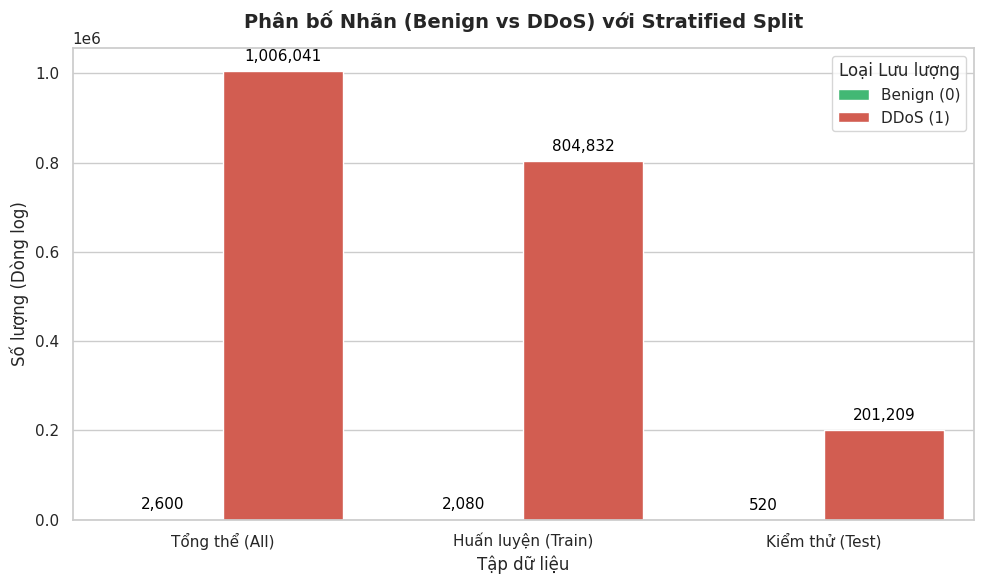

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

print("[*] Đang chia lại dữ liệu cân bằng (Stratified Split)...")
X_train, X_test, y_train, y_test = train_test_split(
    X_top32, y_binary,
    test_size=0.2,
    shuffle=True,          
    stratify=y_binary,     # Ép tỷ lệ chia đều
    random_state=42
)

def plot_current_distribution(y_all, y_tr, y_te):
    def get_counts(y_array):
        unique, counts = np.unique(y_array, return_counts=True)
        count_dict = {0: 0, 1: 0}
        for u, c in zip(unique, counts):
            count_dict[u] = c
        return count_dict[0], count_dict[1]

    all_0, all_1 = get_counts(y_all)
    tr_0, tr_1 = get_counts(y_tr)
    te_0, te_1 = get_counts(y_te)

    print("\n==================================================")
    print(" BÁO CÁO PHÂN BỔ DỮ LIỆU SAU KHI FIX")
    print("==================================================")
    print(f"[-] TỔNG THỂ : {all_0:,} Benign | {all_1:,} DDoS")
    print(f"[-] TẬP TRAIN: {tr_0:,} Benign | {tr_1:,} DDoS")
    print(f"[-] TẬP TEST : {te_0:,} Benign | {te_1:,} DDoS")
    print("==================================================\n")

    data = {
        'Tập dữ liệu': ['Tổng thể (All)', 'Tổng thể (All)',
                        'Huấn luyện (Train)', 'Huấn luyện (Train)',
                        'Kiểm thử (Test)', 'Kiểm thử (Test)'],
        'Nhãn': ['Benign (0)', 'DDoS (1)'] * 3,
        'Số lượng': [all_0, all_1, tr_0, tr_1, te_0, te_1]
    }
    df_plot = pd.DataFrame(data)

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_plot, x='Tập dữ liệu', y='Số lượng', hue='Nhãn', palette=['#2ecc71', '#e74c3c'])

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height):,}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=11, color='black', xytext=(0, 5),
                        textcoords='offset points')

    plt.title('Phân bố Nhãn (Benign vs DDoS) với Stratified Split', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Số lượng (Dòng log)', fontsize=12)
    plt.xlabel('Tập dữ liệu', fontsize=12)
    plt.legend(title='Loại Lưu lượng')
    plt.tight_layout()
    plt.show()

plot_current_distribution(y_binary, y_train, y_test)

# fixed training
🚀 Huấn luyện mô hình Transformer (lưu checkpoint và final model)

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# ĐỊNH NGHĨA CLASS KIẾN TRÚC MÔ HÌNH
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransDDoS_32(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, num_classes=2, seq_len=32):
        super().__init__()
        self.feature_embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        x = x.unsqueeze(-1)  # [batch, 32, 1]
        x = self.feature_embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

# ==========================================
# QUÁ TRÌNH HUẤN LUYỆN
# ==========================================
# Lưu ý: Đảm bảo biến base_path đã được khai báo trước đó.
# Nếu chưa, hãy uncomment và sửa đường dẫn dưới đây:
# base_path = '/content/drive/MyDrive/Internbase-security/transformer-32-feature'

print("[*] Đang tải dữ liệu...")
X_top32 = np.load(os.path.join(base_path, 'datasets/processed', 'X_top32.npy'))
y_binary = np.load(os.path.join(base_path, 'datasets/processed', 'y_binary.npy'))

# 1. CHIA DỮ LIỆU BẰNG STRATIFY
print("[*] Đang chia tập Train/Test (80/20) với tỷ lệ cân bằng...")
X_train, X_test, y_train, y_test = train_test_split(
    X_top32, y_binary,
    test_size=0.2,
    shuffle=True,       
    stratify=y_binary,  
    random_state=42
)

# DataLoader
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. TÍNH TOÁN TRỌNG SỐ VÀ KHỞI TẠO LOSS FUNCTION
print("[*] Đang tính toán trọng số lớp để chống mất cân bằng dữ liệu...")
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransDDoS_32().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. VÒNG LẶP HUẤN LUYỆN LƯU BEST MODEL THEO F1-SCORE
num_epochs = 10
best_f1 = 0.0 # Biến theo dõi F1 tốt nhất
final_model_path = os.path.join(base_path, 'models/final', 'transddos_32.pth')
os.makedirs(os.path.dirname(final_model_path), exist_ok=True)

print(f"[*] Bắt đầu huấn luyện trên {device}...")
for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    # --- VALIDATION (TEST SET) ---
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            out = model(Xb)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            all_preds.extend(pred)
            all_targets.extend(yb.numpy())

    test_acc = accuracy_score(all_targets, all_preds)
    test_f1 = f1_score(all_targets, all_preds, zero_division=0)

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_loss:.4f} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")

    if test_f1 > best_f1:
        best_f1 = test_f1
        torch.save(model.state_dict(), final_model_path)
        print(f"   -> [Cập nhật] Đã lưu Best Model với F1: {best_f1:.4f}")

print("\n[*] Hoàn tất huấn luyện!")

# ==========================================
# XUẤT TORCHSCRIPT CHO MÔI TRƯỜNG THỰC TẾ
# ==========================================
print("[*] Đang xuất TorchScript...")
model.load_state_dict(torch.load(final_model_path))
model.eval()

scripted = torch.jit.script(model)
scripted_path = os.path.join(base_path, 'models/final', 'transddos_32_scripted.pt')
torch.jit.save(scripted, scripted_path)
print(f"✅ Đã lưu TorchScript thành công tại: {scripted_path}")

[*] Đang tải dữ liệu...
[*] Đang chia tập Train/Test (80/20) với tỷ lệ cân bằng...
[*] Đang tính toán trọng số lớp để chống mất cân bằng dữ liệu...
[*] Bắt đầu huấn luyện trên cuda...
Epoch 01 | Train Loss: 0.3963 | Test Acc: 0.9974 | Test F1: 0.9987
   -> [Cập nhật] Đã lưu Best Model với F1: 0.9987
Epoch 02 | Train Loss: 0.3892 | Test Acc: 0.9974 | Test F1: 0.9987
Epoch 03 | Train Loss: 0.1091 | Test Acc: 0.9995 | Test F1: 0.9997
   -> [Cập nhật] Đã lưu Best Model với F1: 0.9997
Epoch 04 | Train Loss: 0.0572 | Test Acc: 0.9993 | Test F1: 0.9996
Epoch 05 | Train Loss: 0.0636 | Test Acc: 0.9995 | Test F1: 0.9997
Epoch 06 | Train Loss: 0.0434 | Test Acc: 0.9989 | Test F1: 0.9995
Epoch 07 | Train Loss: 0.0567 | Test Acc: 0.9994 | Test F1: 0.9997
Epoch 08 | Train Loss: 0.0306 | Test Acc: 0.9995 | Test F1: 0.9997
Epoch 09 | Train Loss: 0.0257 | Test Acc: 0.9995 | Test F1: 0.9998
   -> [Cập nhật] Đã lưu Best Model với F1: 0.9998
Epoch 10 | Train Loss: 0.0184 | Test Acc: 0.9993 | Test F1: 0.9

###📊 Đánh giá mô hình sau huấn luyện

✅ Đã tải mô hình từ /content/drive/MyDrive/Internbase-security/transformer-32-feature/models/final/transddos_32.pth
[*] Đang đánh giá mô hình trên tập dữ liệu Test...

[+] KẾT QUẢ ĐÁNH GIÁ (tương đương Bảng 2 bài báo):
    - Accuracy : 0.9995 (99.95%)
    - Precision: 1.0000 (100.00%)
    - Recall   : 0.9996 (99.96%)
    - F1-Score : 0.9998 (99.98%)

[+] BÁO CÁO PHÂN LOẠI CHI TIẾT:
              precision    recall  f1-score   support

  Benign (0)     0.8517    0.9942    0.9175       520
    DDoS (1)     1.0000    0.9996    0.9998    201209

    accuracy                         0.9995    201729
   macro avg     0.9259    0.9969    0.9586    201729
weighted avg     0.9996    0.9995    0.9996    201729



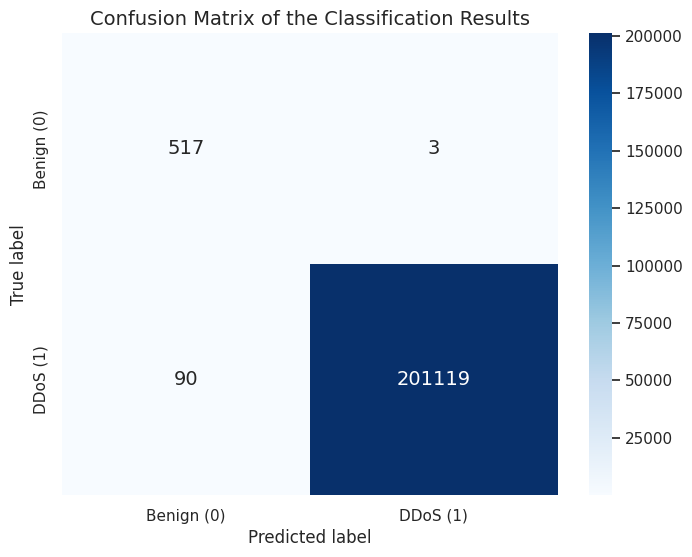


[*] Đang biên dịch mô hình sang TorchScript (Dùng hàm Script)...
✅ Đã lưu TorchScript model siêu tốc tại: /content/drive/MyDrive/Internbase-security/transformer-32-feature/models/final/transddos_32_scripted.pt


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os

# 1. Xác định đường dẫn
base_path = '/content/drive/MyDrive/Internbase-security/transformer-32-feature'
model_path = os.path.join(base_path, 'models/final', 'transddos_32.pth')
scaler_path = os.path.join(base_path, 'models/final', 'minmax_scaler_32feat.pkl')

# 2. Tải lại kiến trúc mô hình 
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransDDoS_32(nn.Module):
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, num_classes=2, seq_len=32):
        super().__init__()
        self.feature_embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        # x shape: [batch, 32] (32 features)
        x = x.unsqueeze(-1)  # [batch, 32, 1]
        x = self.feature_embedding(x)  # [batch, 32, d_model]
        x = self.pos_encoder(x)
        x = self.transformer(x)        # [batch, 32, d_model]
        x = x.mean(dim=1)              # [batch, d_model]
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransDDoS_32().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"✅ Đã tải mô hình từ {model_path}")

# Load lại dữ liệu test đã lưu (X_test, y_test)
X_top32 = np.load(os.path.join(base_path, 'datasets/processed', 'X_top32.npy'))
y_binary = np.load(os.path.join(base_path, 'datasets/processed', 'y_binary.npy'))

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X_top32, y_binary,
    test_size=0.2,
    shuffle=True,       
    stratify=y_binary,  
    random_state=42     
)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import DataLoader, TensorDataset
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Đánh giá
all_preds = []
all_labels = []

print("[*] Đang đánh giá mô hình trên tập dữ liệu Test...")
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        out = model(Xb)
        pred = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(yb.numpy())

# Tính các chỉ số
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)

print("\n==================================================")
print("[+] KẾT QUẢ ĐÁNH GIÁ (tương đương Bảng 2 bài báo):")
print(f"    - Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"    - Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"    - Recall   : {rec:.4f} ({rec*100:.2f}%)")
print(f"    - F1-Score : {f1:.4f} ({f1*100:.2f}%)")
print("==================================================\n")

print("[+] BÁO CÁO PHÂN LOẠI CHI TIẾT:")
print(classification_report(all_labels, all_preds, target_names=['Benign (0)', 'DDoS (1)'], digits=4))

# 5. Vẽ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'DDoS (1)'],
            yticklabels=['Benign (0)', 'DDoS (1)'],
            annot_kws={"size": 14})
plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.title('Confusion Matrix of the Classification Results', fontsize=14)
plt.show()


# 6. Xuất TorchScript cho inference
try:
    print("\n[*] Đang biên dịch mô hình sang TorchScript (Dùng hàm Script)...")
    scripted_model = torch.jit.script(model)
    scripted_path = os.path.join(
        base_path,
        'models/final',
        'transddos_32_scripted.pt'
    )
    scripted_model.save(scripted_path)
    print(f"✅ Đã lưu TorchScript model siêu tốc tại: {scripted_path}")
except Exception as e:
    print(f"⚠️ Không thể tạo TorchScript: {e}")

###🚀 Huấn luyện mô hình Transformer (lưu checkpoint và final model)

In [ ]:
import numpy as np

unique, counts = np.unique(y_binary, return_counts=True)
label_distribution = dict(zip(unique, counts))
print("📊 Phân bố nhãn:", label_distribution)


📊 Phân bố nhãn: {np.int64(0): np.int64(2600), np.int64(1): np.int64(1006041)}


### ✨ Các trường (features) hàng đầu được chọn

In [ ]:
import os

# Đường dẫn đến file chứa 32 features
base_path = '/content/drive/MyDrive/Internbase-security/transformer-32-feature'
features_path = os.path.join(base_path, 'datasets/processed', 'top32_features.txt')

print("Danh sách 32 Features được chọn:")
with open(features_path, 'r') as f:
    for i, line in enumerate(f):
        print(f"{i+1}. {line.strip()}")

Danh sách 32 Features được chọn:
1. Inbound
2. URG Flag Count
3. Bwd Packet Length Mean
4. Bwd Packet Length Max
5. Source Port
6. Min Packet Length
7. Avg Bwd Segment Size
8. Total Length of Bwd Packets
9. Bwd Packet Length Min
10. Subflow Bwd Bytes
11. act_data_pkt_fwd
12. Init_Win_bytes_forward
13. Total Length of Fwd Packets
14. Subflow Fwd Bytes
15. Packet Length Variance
16. Destination Port
17. Init_Win_bytes_backward
18. CWE Flag Count
19. RST Flag Count
20. Fwd PSH Flags
21. Average Packet Size
22. Fwd Packet Length Min
23. Fwd Packet Length Mean
24. Packet Length Mean
25. Packet Length Std
26. Flow Bytes/s
27. Subflow Fwd Packets
28. Fwd Packet Length Std
29. Flow IAT Max
30. Down/Up Ratio
31. Fwd Packet Length Max
32. Avg Fwd Segment Size


In [ ]:
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Internbase-security/transformer-32-feature'

base_dir = Path(base_path)

print("\n==================================================")
print("📂 DANH SÁCH CÁC FILE ĐÃ ĐƯỢC TẠO TRONG DỰ ÁN")
print("==================================================")

if not base_dir.exists():
    print(f"⚠️ Không tìm thấy thư mục: {base_dir}")
    print("Vui lòng kiểm tra lại đường dẫn hoặc kết nối Google Drive!")
else:
    for path in sorted(base_dir.rglob('*')):
        if path.is_file() and '.ipynb_checkpoints' not in path.parts:
            relative_path = path.relative_to(base_dir)

            if path.suffix == '.json':
                print(f"📊 {relative_path}")
            elif path.suffix in ['.pth', '.pt']:
                print(f"🧠 {relative_path}")
            elif path.suffix == '.csv':
                print(f"📈 {relative_path}")
            else:
                print(f"📄 {relative_path}")

print("==================================================")

Mounted at /content/drive

📂 DANH SÁCH CÁC FILE ĐÃ ĐƯỢC TẠO TRONG DỰ ÁN
📄 datasets/processed/X_top32.npy
📄 datasets/processed/cicddos2019_5percent.parquet
📄 datasets/processed/top32_features.txt
📄 datasets/processed/y_binary.npy
📄 datasets/raw/cicddos2019_5percent.zip
📄 models/final/minmax_scaler_32feat.pkl
🧠 models/final/transddos_32.pth
🧠 models/final/transddos_32_scripted.pt


In [ ]:
import json
from datetime import datetime
from pathlib import Path

metrics_dir = Path(base_path) / 'results' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

results_dict = {
    "model_name": "TransDDoS_32",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "evaluation_metrics": {
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4)
    },
    "confusion_matrix": {
        "True_Negative": int(cm[0, 0]),
        "False_Positive": int(cm[0, 1]),
        "False_Negative": int(cm[1, 0]),
        "True_Positive": int(cm[1, 1])
    }
}

# Lưu thành file JSON
json_path = metrics_dir / 'evaluation_results.json'
with json_path.open('w', encoding='utf-8') as f:
    json.dump(results_dict, f, indent=4)

print(f"✅ Đã xuất báo cáo JSON thành công tại: {json_path}")

In [ ]:
import pandas as pd
from datetime import datetime
from pathlib import Path

metrics_dir = Path(base_path) / 'results' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)
csv_path = metrics_dir / 'model_comparison.csv'

new_result = pd.DataFrame([{
    "Date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "Model": "TransDDoS_32",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1_Score": f1
}])

if csv_path.exists():
    new_result.to_csv(csv_path, mode='a', header=False, index=False)
    print(f"✅ Đã cập nhật kết quả vào file CSV: {csv_path}")
else:
    new_result.to_csv(csv_path, mode='w', header=True, index=False)
    print(f"✅ Đã tạo mới file CSV báo cáo tại: {csv_path}")